### Imports

In [1]:
import os, sys

# Go to the repo root (adjust path if needed)
%cd /content/Data-Science-Project

# Make sure repo root is on sys.path
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.append(repo_root)

print("Using repo_root:", repo_root)

/content/Data-Science-Project
Using repo_root: /content/Data-Science-Project


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from data.crisismmd import (
    load_crisismmd_annotations,
    CrisisVisionDataset,
    make_train_transforms,
    make_eval_transforms,
)
from models.vision_branch import build_resnet_classifier, VisionDatasetWrapper
from training.utils import train_one_epoch, evaluate

### Load CrisisMMD dataset

In [3]:
# Root directory where you extracted CrisisMMD_v2.0
root = "../CrisisMMD_v2.0"  # adjust if needed

# Load and merge all annotation .tsv files
combined = load_crisismmd_annotations(root)

# Keep the columns we care about
dataset_df = combined[["tweet_id", "image_id", "text_info", "image_info", "tweet_text", "image_path"]]

# Split into train / validation
train_df, val_df = train_test_split(dataset_df, test_size=0.2, random_state=42)

# Transforms
train_tf = make_train_transforms()
val_tf   = make_eval_transforms()

# Base datasets: each returns (image_tensor, label)
base_train_ds = CrisisVisionDataset(train_df, root_dir=root, transform=train_tf)
base_val_ds   = CrisisVisionDataset(val_df,   root_dir=root, transform=val_tf)

# Wrapped datasets: each returns ((image_tensor,), label)
train_ds = VisionDatasetWrapper(base_train_ds)
val_ds   = VisionDatasetWrapper(base_val_ds)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)

# Quick sanity check
images_batch, labels_batch = next(iter(train_loader))
print("Batch images shape:", images_batch[0].shape)  # images_batch is a tuple with one tensor
print("Batch labels shape:", labels_batch.shape)

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])


### Build model, criterion and optimizer

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = build_resnet_classifier(num_classes=2, pretrained=True).to(device)

# Freeze everything, then unfreeze layer4 and fc (as in your original notebook)
for p in model.parameters():
    p.requires_grad = False
for p in model.layer4.parameters():
    p.requires_grad = True
for p in model.fc.parameters():
    p.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    [
        {"params": model.layer4.parameters(), "lr": 1e-4},
        {"params": model.fc.parameters(),     "lr": 1e-3},
    ]
)

EPOCHS = 3  # or 10 if you want to match your previous longer training

train_loss_hist = []
train_acc_hist  = []
val_loss_hist   = []
val_acc_hist    = []


Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s] 


### Train the model

In [5]:
print("Starting ResNet training...")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # train_one_epoch / evaluate from training/utils.py
    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_loss, val_acc, _, _ = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

print("\nTraining complete.")

Starting ResNet training...

Epoch 1/3


  6%|▌         | 25/453 [00:10<02:18,  3.08it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


train_loss=0.4350, train_acc=0.7971, val_loss=0.4019, val_acc=0.8156

Epoch 2/3


 13%|█▎        | 61/453 [00:22<02:32,  2.57it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


train_loss=0.3264, train_acc=0.8567, val_loss=0.4372, val_acc=0.7891

Epoch 3/3


 60%|██████    | 274/453 [01:43<01:22,  2.16it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
 75%|███████▌  | 341/453 [02:09<00:40,  2.76it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


train_loss=0.2523, train_acc=0.8937, val_loss=0.4212, val_acc=0.8206

Training complete.


### Save model weights

In [6]:
os.makedirs("../checkpoints", exist_ok=True)
vision_path = "../checkpoints/vision_brain.pth"
torch.save(model.state_dict(), vision_path)
print(f"Saved ResNet vision model to {vision_path}")

Saved ResNet vision model to ../checkpoints/vision_brain.pth


### Plot train/val curves

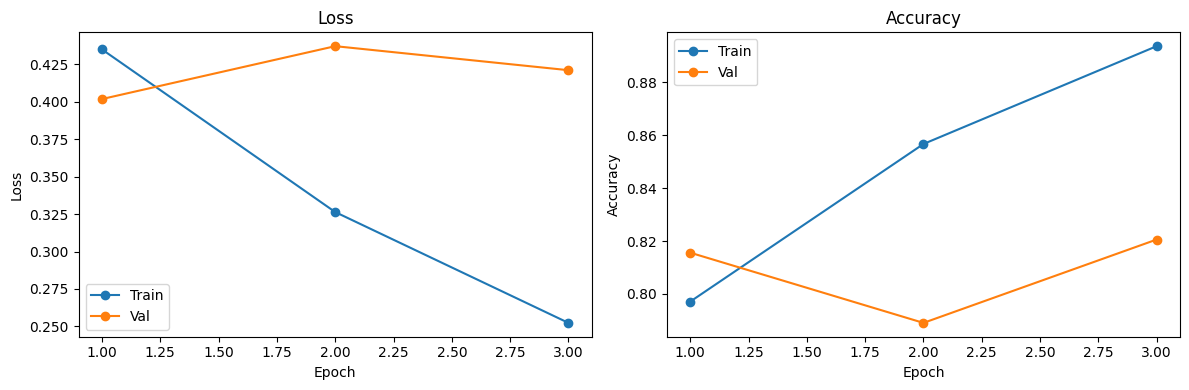

In [7]:
epochs = np.arange(1, EPOCHS + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax[0].plot(epochs, train_loss_hist, marker="o", label="Train")
ax[0].plot(epochs, val_loss_hist,   marker="o", label="Val")
ax[0].set_title("Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Accuracy curves
ax[1].plot(epochs, train_acc_hist, marker="o", label="Train")
ax[1].plot(epochs, val_acc_hist,   marker="o", label="Val")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()

### Evaluation and confusion matrix


--- VISION MODEL (RESNET) VALIDATION RESULTS ---
Val Accuracy: 82.06%
Val F1 Score: 0.8170


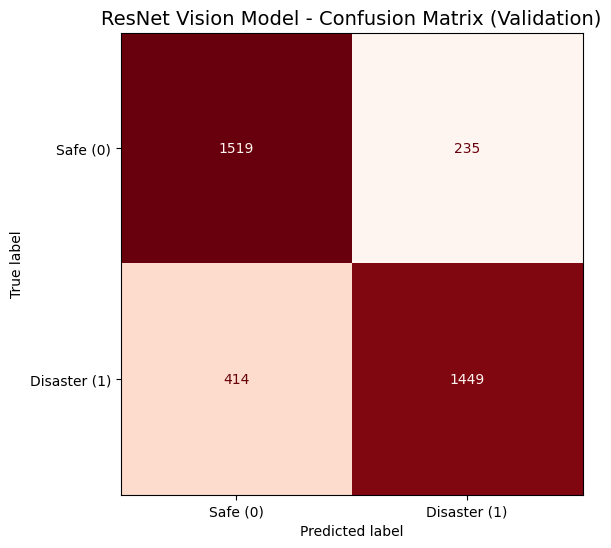

In [8]:
# Re-use evaluate to get predictions
val_loss, val_acc, val_preds, val_true = evaluate(
    model=model,
    loader=val_loader,
    criterion=criterion,
    device=device,
)

val_f1 = f1_score(val_true, val_preds, average="binary")

print("\n--- VISION MODEL (RESNET) VALIDATION RESULTS ---")
print(f"Val Accuracy: {val_acc * 100:.2f}%")
print(f"Val F1 Score: {val_f1:.4f}")

cm = confusion_matrix(val_true, val_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Safe (0)", "Disaster (1)"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Reds", ax=ax, colorbar=False)
plt.title("ResNet Vision Model - Confusion Matrix (Validation)", fontsize=14)
plt.grid(False)
plt.show()